# Pharmacokinetics Dosing with Discrete Events and Forcing Functions

This notebook demonstrates the unified use of **Discrete Event Schedulers** and **Right-Hand Side (RHS) Forcing Functions** in the **PyMCSimMod** package. 

### Concepts:
1. **Discrete Events / Event Schedulers**: Modifies state variables instantaneously at precise times (e.g. drug dosing to `A0` or `A1` compartments). In this example, we use the `NDoses` and `PerDoses` built-in event schedulers.
2. **Forcing Functions**: Used to represent time-dependent non-state variables (e.g., body mass `M_in` using the `ConstFunc` or `Interpolate` forcing functions).

Both SciPy (`ScipyModel`) and JAX (`JaxModel` / `EqxModel`) backends are fully compatible with this unified workflow. For JAX, discrete events are solved segment-by-segment using a JAX-native `jax.lax.scan` routine, ensuring full compatibility with automatic differentiation (`jax.grad`) and compilation (`jax.jit`).

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import importlib.resources

from pymcsimmod import create_model, ScipyModel, JaxModel
from pymcsimmod.events import PerDoses, NDoses, OnOff, DataFrameEventScheduler
import pandas as pd

## 1. SciPy Model Simulation: Weekly Dosing with Growth

We simulate a weekly oral dosing schedule (`OralDose = 50 mg` administered every 7 days to state variable `A0`) of a growing subject (body weight `M_in` interpolated from 20 kg to 90 kg over 35 days).

C:\Users\tjzur\models\PyMCSimMod\src\pymcsimmod\models\scipy_model.py:204: UserWarning: Event times [np.float64(7.0), np.float64(14.0), np.float64(21.0), np.float64(28.0)] not found in time grid - automatically adding them to ensure accurate event handling. To avoid this message, consider using: np.arange(0.0, 35.035, 0.035) or explicitly include event times in your time array.
  validated_events, modified_times = check_events(self.events, times, self.state_names)
C:\Users\tjzur\models\PyMCSimMod\src\pymcsimmod\models\scipy_model.py:204: UserWarning: Removed 2 time points that were within numerical precision of event times to avoid numerical issues. This is normal behavior following deSolve's event handling.
  validated_events, modified_times = check_events(self.events, times, self.state_names)


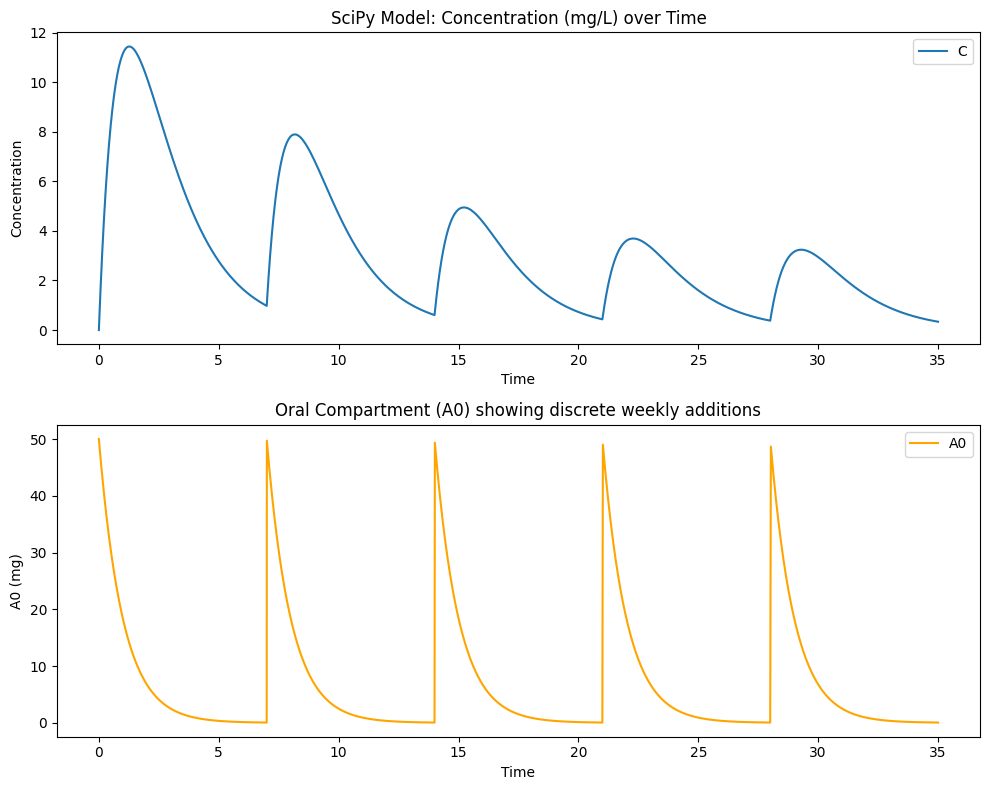

In [2]:
with importlib.resources.path('pymcsimmod.data', 'pk1_input.model') as filename:
    scipy_model = create_model(filename, backend="scipy")

# Set the oral dose parameter
scipy_model.update_constants(OralDose=50.0)

# 1. Define time-varying body mass using a forcing function
time_points = [0, 7, 14, 21, 28, 35]
bodyweights = [20, 30, 50, 70, 80, 90]
scipy_model.assign_forcing_function('M_in', 'Interpolate', times=time_points, values=bodyweights)

# 2. Define weekly dosing using an event scheduler
# This schedules +50 mg to A0 every 7 days starting at t=0
scipy_model.assign_event('A0', 'PerDoses', t0=0.0, period=7.0, value=scipy_model.parameters['OralDose'])

# Run simulation
times = np.linspace(0, 35, 1000)
solution = scipy_model.run_model(times)

# Plot results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
solution.plot_results(variables='C', ax=ax1)
ax1.set_title('SciPy Model: Concentration (mg/L) over Time')
ax1.set_ylabel('Concentration')

solution.plot_results(variables='A0', ax=ax2, color='orange')
ax2.set_title('Oral Compartment (A0) showing discrete weekly additions')
ax2.set_ylabel('A0 (mg)')

plt.tight_layout()
plt.show()

## 2. JAX Model Simulation: Weekly Dosing with Growth

We run the exact same simulation using the JAX backend. This compiles and integrates the segments between event times automatically.

C:\Users\tjzur\models\PyMCSimMod\src\pymcsimmod\models\jax_model.py:127: UserWarning: Event times [np.float64(7.0), np.float64(14.0), np.float64(21.0), np.float64(28.0)] not found in time grid - automatically adding them to ensure accurate event handling. To avoid this message, consider using: np.arange(0.0, 35.035, 0.035) or explicitly include event times in your time array.
  validated_events, modified_times = check_events(
C:\Users\tjzur\models\PyMCSimMod\src\pymcsimmod\models\jax_model.py:127: UserWarning: Removed 2 time points that were within numerical precision of event times to avoid numerical issues. This is normal behavior following deSolve's event handling.
  validated_events, modified_times = check_events(


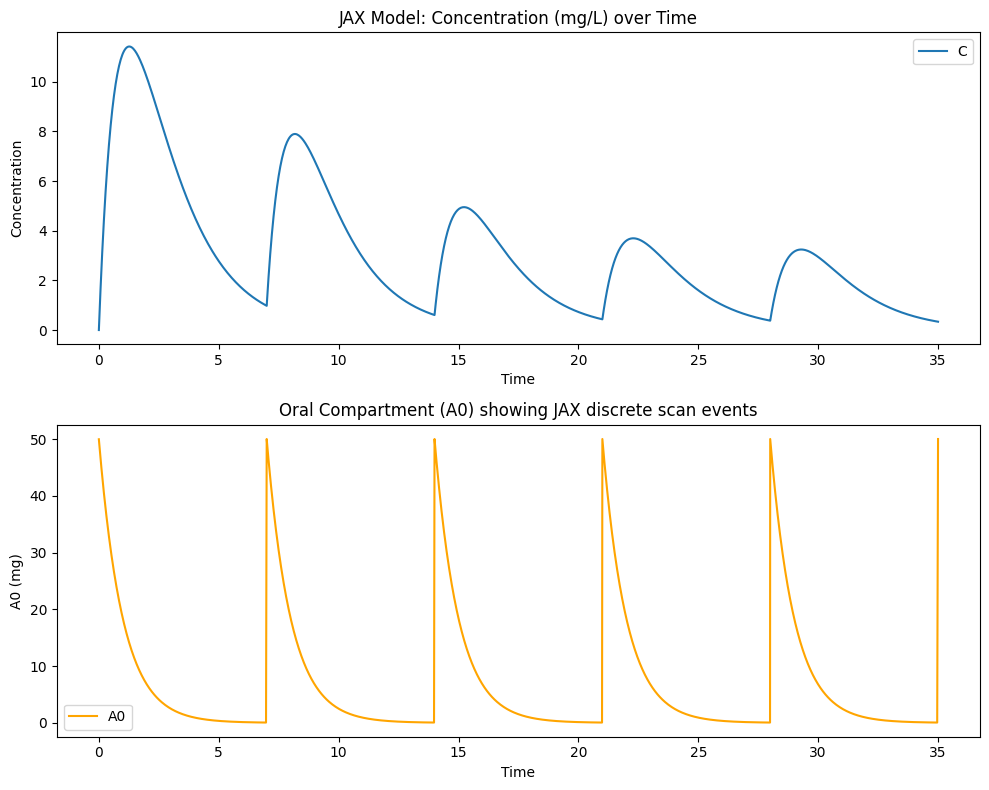

In [3]:
with importlib.resources.path('pymcsimmod.data', 'pk1_input.model') as filename:
    jax_model = create_model(filename, backend="jax")

# Set the oral dose parameter
jax_model.update_constants(OralDose=50.0)

# 1. Define time-varying body mass using a forcing function
jax_model.assign_forcing_function('M_in', 'Interpolate', times=time_points, values=bodyweights)

# 2. Define weekly dosing using an event scheduler
jax_model.assign_event('A0', 'PerDoses', t0=0.0, period=7.0, value=jax_model.parameters['OralDose'])

# Run simulation
times = np.linspace(0, 35, 1000)
solution_jax = jax_model.run_model(times)

# Plot results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
solution_jax.plot_results(variables='C', ax=ax1)
ax1.set_title('JAX Model: Concentration (mg/L) over Time')
ax1.set_ylabel('Concentration')

solution_jax.plot_results(variables='A0', ax=ax2, color='orange')
ax2.set_title('Oral Compartment (A0) showing JAX discrete scan events')
ax2.set_ylabel('A0 (mg)')

plt.tight_layout()
plt.show()

## 3. Combined Oral and IV Dosing (Multiple Schedulers)

Here, we schedule both **oral dosing** (weekly `PerDoses` scheduler on `A0` with `value=50.0`) and **IV bolus dosing** (custom `NDoses` scheduler on `A1` with `value=100.0` at t=10 and t=25) for a subject with constant body weight of 70 kg.

C:\Users\tjzur\models\PyMCSimMod\src\pymcsimmod\models\jax_model.py:127: UserWarning: Event times [np.float64(7.0), np.float64(10.0), np.float64(14.0), np.float64(21.0), np.float64(25.0), np.float64(28.0)] not found in time grid - automatically adding them to ensure accurate event handling. To avoid this message, consider using: np.arange(0.0, 35.035, 0.035) or explicitly include event times in your time array.
  validated_events, modified_times = check_events(


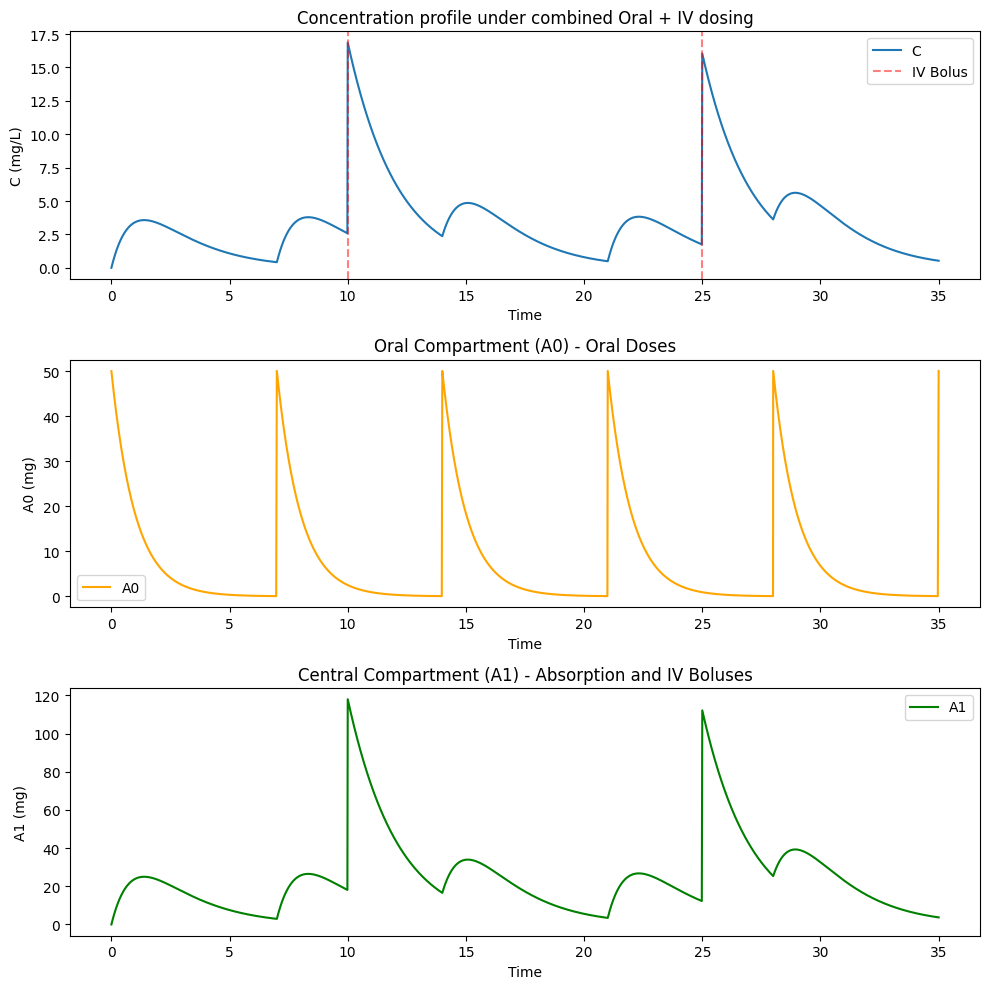

In [4]:
with importlib.resources.path('pymcsimmod.data', 'pk1_input.model') as filename:
    jax_multi = create_model(filename, backend="jax")

jax_multi.update_constants(OralDose=50.0, IVDose=100.0)
jax_multi.assign_forcing_function('M_in', 'ConstFunc', value=70.0)

# Assign oral dosing schedule on A0
jax_multi.assign_event('A0', 'PerDoses', t0=0.0, period=7.0, value=jax_multi.parameters['OralDose'])

# Add IV bolus dosing schedule on A1 at t=10.0 and t=25.0
iv_sched = NDoses(t0_list=[10.0, 25.0], value=jax_multi.parameters['IVDose'])
jax_multi.add_event_scheduler('A1', iv_sched)

# Run simulation
times = np.linspace(0, 35, 1000)
solution_multi = jax_multi.run_model(times)

# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10))

# Plot concentration
solution_multi.plot_results(variables='C', ax=ax1)
ax1.set_title('Concentration profile under combined Oral + IV dosing')
ax1.set_ylabel('C (mg/L)')
ax1.axvline(x=10, color='red', linestyle='--', alpha=0.5, label='IV Bolus')
ax1.axvline(x=25, color='red', linestyle='--', alpha=0.5)
ax1.legend()

# Plot A0
solution_multi.plot_results(variables='A0', ax=ax2, color='orange')
ax2.set_title('Oral Compartment (A0) - Oral Doses')
ax2.set_ylabel('A0 (mg)')

# Plot A1
solution_multi.plot_results(variables='A1', ax=ax3, color='green')
ax3.set_title('Central Compartment (A1) - Absorption and IV Boluses')
ax3.set_ylabel('A1 (mg)')

plt.tight_layout()
plt.show()

## 4. Constant vs. Growth Body Weight (Impact of Forcing Functions)

We compare how the concentration profile of a subject receiving weekly oral doses changes when body weight is assumed constant (70 kg) versus growing (20 kg to 90 kg).

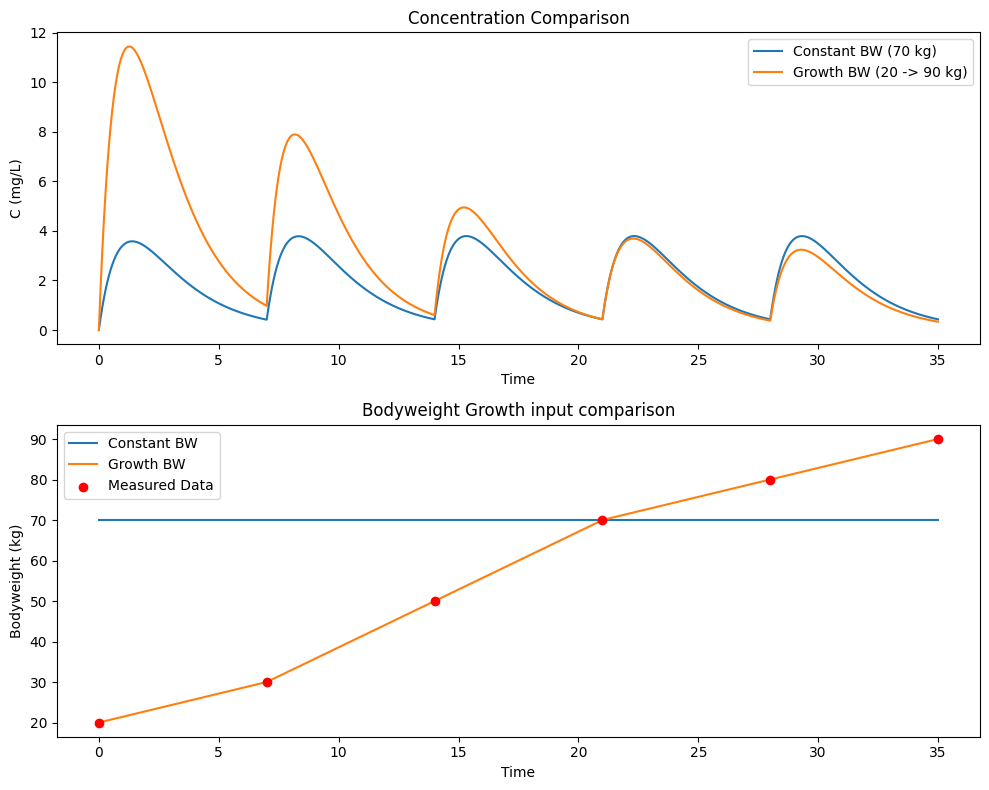

In [5]:
# 1. Model with Constant Bodyweight (70 kg)
with importlib.resources.path('pymcsimmod.data', 'pk1_input.model') as filename:
    model_const = create_model(filename, backend="scipy")
model_const.update_constants(OralDose=50.0)
model_const.assign_forcing_function('M_in', 'ConstFunc', value=70.0)
model_const.assign_event('A0', 'PerDoses', t0=0.0, period=7.0, value=model_const.parameters['OralDose'])
sol_const = model_const.run_model(times)

# 2. Model with Time-varying (Growth) Bodyweight
with importlib.resources.path('pymcsimmod.data', 'pk1_input.model') as filename:
    model_growth = create_model(filename, backend="scipy")
model_growth.update_constants(OralDose=50.0)
model_growth.assign_forcing_function('M_in', 'Interpolate', times=time_points, values=bodyweights)
model_growth.assign_event('A0', 'PerDoses', t0=0.0, period=7.0, value=model_growth.parameters['OralDose'])
sol_growth = model_growth.run_model(times)

# Compare profiles
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

sol_const.plot_results(variables='C', ax=ax1, labels={'C': 'Constant BW (70 kg)'})
sol_growth.plot_results(variables='C', ax=ax1, labels={'C': 'Growth BW (20 -> 90 kg)'})
ax1.set_title('Concentration Comparison')
ax1.set_ylabel('C (mg/L)')
ax1.legend()

sol_const.plot_inputs(variables='M_in', ax=ax2, labels={'M_in': 'Constant BW'})
sol_growth.plot_inputs(variables='M_in', ax=ax2, labels={'M_in': 'Growth BW'})
ax2.scatter(time_points, bodyweights, color='red', zorder=5, label='Measured Data')
ax2.set_title('Bodyweight Growth input comparison')
ax2.set_ylabel('Bodyweight (kg)')
ax2.legend()

plt.tight_layout()
plt.show()

## 5. DataFrame Dosing (DataFrameEventScheduler)

Here, we demonstrate using a pandas `DataFrame` to define a list of discrete doses and run the simulation using the `DataFrameEventScheduler`.

Dosing Schedule DataFrame:
   time  value method
0   2.5   40.0    add
1   5.0   60.0    add
2  12.5   80.0    add
3  20.0   50.0    add
4  31.0   70.0    add


C:\Users\tjzur\models\PyMCSimMod\src\pymcsimmod\models\scipy_model.py:204: UserWarning: Event times [np.float64(2.5), np.float64(5.0), np.float64(12.5), np.float64(20.0), np.float64(31.0)] not found in time grid - automatically adding them to ensure accurate event handling. To avoid this message, consider using: np.arange(0.0, 35.035, 0.035) or explicitly include event times in your time array.
  validated_events, modified_times = check_events(self.events, times, self.state_names)
C:\Users\tjzur\models\PyMCSimMod\src\pymcsimmod\models\jax_model.py:127: UserWarning: Event times [np.float64(2.5), np.float64(5.0), np.float64(12.5), np.float64(20.0), np.float64(31.0)] not found in time grid - automatically adding them to ensure accurate event handling. To avoid this message, consider using: np.arange(0.0, 35.035, 0.035) or explicitly include event times in your time array.
  validated_events, modified_times = check_events(


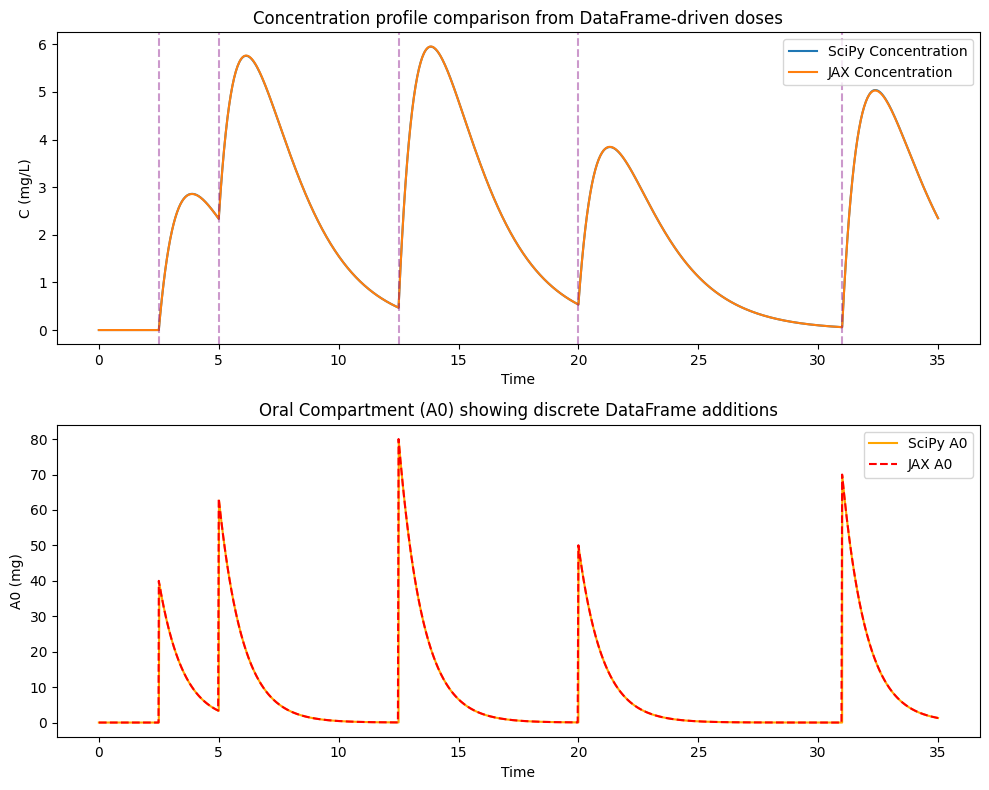

In [6]:
# 1. Create a pandas DataFrame with dose times and values
dosing_df = pd.DataFrame({
    'time': [2.5, 5.0, 12.5, 20.0, 31.0],
    'value': [40.0, 60.0, 80.0, 50.0, 70.0],
    'method': ['add', 'add', 'add', 'add', 'add']
})
print('Dosing Schedule DataFrame:')
print(dosing_df)

# 2. Build the model using both SciPy and JAX backends
with importlib.resources.path('pymcsimmod.data', 'pk1_input.model') as filename:
    model_df_scipy = create_model(filename, backend="scipy")
    model_df_jax = create_model(filename, backend="jax")

model_df_scipy.assign_forcing_function('M_in', 'ConstFunc', value=70.0)
model_df_jax.assign_forcing_function('M_in', 'ConstFunc', value=70.0)

# 3. Assign the DataFrame events to the models using assign_event
model_df_scipy.assign_event('A0', 'DataFrame', df=dosing_df)
model_df_jax.assign_event('A0', 'DataFrame', df=dosing_df)

# Run simulations
times = np.linspace(0, 35, 1000)
solution_scipy = model_df_scipy.run_model(times)
solution_jax = model_df_jax.run_model(times)

# Plot results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
solution_scipy.plot_results(variables='C', ax=ax1, labels={'C': 'SciPy Concentration'})
solution_jax.plot_results(variables='C', ax=ax1, labels={'C': 'JAX Concentration'})
ax1.set_title('Concentration profile comparison from DataFrame-driven doses')
ax1.set_ylabel('C (mg/L)')
ax1.legend()
for t in dosing_df['time']:
    ax1.axvline(x=t, color='purple', linestyle='--', alpha=0.4)

solution_scipy.plot_results(variables='A0', ax=ax2, color='orange', labels={'A0': 'SciPy A0'})
solution_jax.plot_results(variables='A0', ax=ax2, color='red', linestyle='--', labels={'A0': 'JAX A0'})
ax2.set_title('Oral Compartment (A0) showing discrete DataFrame additions')
ax2.set_ylabel('A0 (mg)')
ax2.legend()

plt.tight_layout()
plt.show()